<a href="https://colab.research.google.com/github/jpegiel/QCR/blob/main/RSA_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy

def gcd(a, h):
    while(h != 0):
        a, h = h, a % h
    return a

# Key Generation
p = 89
q = 67
n = p * q
phi = (p - 1) * (q - 1)

e = 2
while (e < phi):
    if(gcd(e, phi) == 1):
        break
    else:
        e += 1

d = pow(e, -1, phi)

# Encryption and Decryption Demonstration
original_msg = 12
ciphertext = pow(original_msg, e, n)
decrypted_msg = pow(ciphertext, d, n)

print(f"Original Message: {original_msg}")

# Intercept Demonstration
factors = sympy.factorint(n)
p_crack, q_crack = list(factors.keys())
phi_crack = (p_crack - 1) * (q_crack - 1)
d_crack = pow(e, -1, phi_crack)

recovered_msg = pow(ciphertext, d_crack, n)
print(f"Recovered Message (by attacker): {recovered_msg}")

Original Message: 12
Recovered Message (by attacker): 12


STATISTICS

--- Comparing Decryption Time vs. Security Bit Level (Prime Size) ---

Testing with 16-bit primes...
  Decryption Time: 0.00000739 seconds

Testing with 32-bit primes...
  Decryption Time: 0.00001931 seconds

Testing with 64-bit primes...
  Decryption Time: 0.00005054 seconds

Testing with 128-bit primes...
  Decryption Time: 0.00020027 seconds

Testing with 256-bit primes...
  Decryption Time: 0.00098920 seconds

Testing with 512-bit primes...
  Decryption Time: 0.00606608 seconds


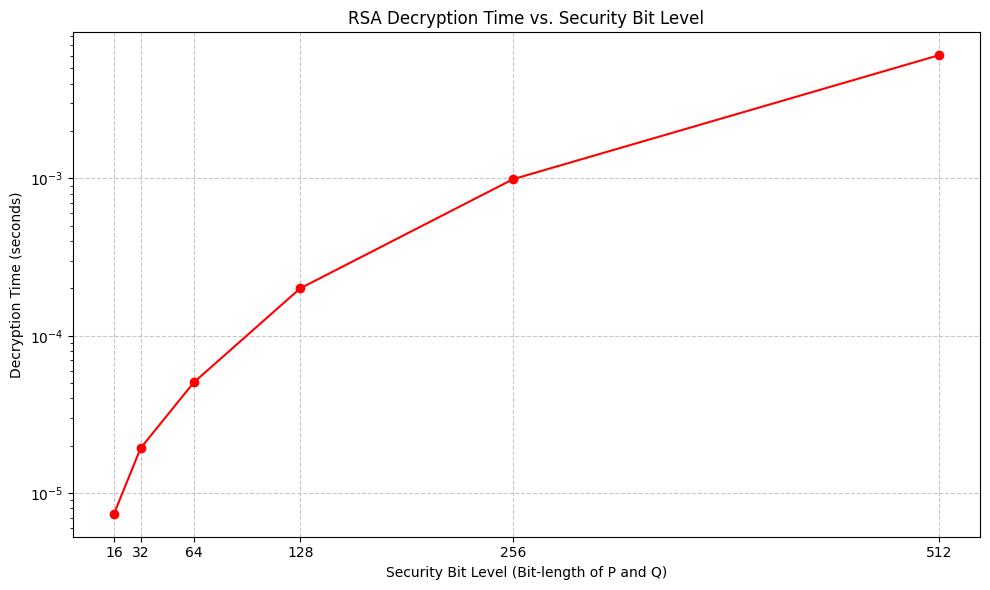


This plot clearly demonstrates how the RSA decryption time scales with increasing security bit levels. As expected, cryptographic operations become significantly more computationally intensive with larger prime numbers, which offer stronger security. The logarithmic y-axis helps in visualizing the rapid increase.


In [ ]:
import time
import matplotlib.pyplot as plt
import sympy
import random

# Ensure gcd is available for use here. It is defined in an earlier cell, but including it
# for robustness if this cell is run independently.
def gcd(a, h):
    temp = 0
    while(1):
        temp = a % h
        if (temp == 0):
            return h
        a = h
        h = temp

print("--- Comparing Decryption Time vs. Security Bit Level (Prime Size) ---")

# Define different security bit levels (bit-length of p and q)
# These represent the bit length of each prime (p and q).
bit_lengths = [16, 32, 64, 128, 256, 512] # Providing 6 points
decryption_times = []

# A common choice for the public exponent (e)
FIXED_E = 65537

for bit_length in bit_lengths:
    print(f"\nTesting with {bit_length}-bit primes...")

    # Generate two distinct random primes of the specified bit_length
    p = sympy.randprime(2**(bit_length-1), 2**bit_length - 1)
    q = sympy.randprime(2**(bit_length-1), 2**bit_length - 1)

    while p == q:
        q = sympy.randprime(2**(bit_length-1), 2**bit_length - 1)

    n = p * q
    phi = (p - 1) * (q - 1)

    # Choose public exponent e. Using a fixed e = 65537 for consistency.
    # This e is usually coprime to phi, especially for large random primes.
    e = FIXED_E
    if gcd(e, phi) != 1:
        # Fallback if FIXED_E is not coprime (unlikely for these sizes with random primes)
        # For simplicity and to avoid very long loops, this case is minimally handled
        # In a real application, more robust prime/e generation would be used.
        print(f"  Warning: Fixed e ({FIXED_E}) was not coprime to phi, attempting to find a random suitable e.")
        e = random.randint(2, phi - 1)
        while gcd(e, phi) != 1:
            e = random.randint(2, phi - 1)
        print(f"  Selected random e: {e}")

    # Calculate private exponent d
    d = pow(e, -1, phi)

    # Generate a random message to encrypt (must be less than n)
    msg = random.randint(2, n - 1)

    # Encrypt the message to get the ciphertext (c)
    # We need c to perform decryption, but are not measuring encryption time here.
    c = pow(msg, e, n)

    # Measure decryption time
    start_time = time.time()
    m_decrypted = pow(c, d, n)
    end_time = time.time()
    decryption_time = end_time - start_time

    decryption_times.append(decryption_time)
    print(f"  Decryption Time: {decryption_time:.8f} seconds")


# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(bit_lengths, decryption_times, marker='o', linestyle='-', color='red')
plt.xlabel('Security Bit Level (Bit-length of P and Q)')
plt.ylabel('Decryption Time (seconds)')
plt.title('RSA Decryption Time vs. Security Bit Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(bit_lengths) # Ensure all bit_lengths are shown as ticks
plt.yscale('log') # Use a logarithmic scale for y-axis to better visualize exponential growth
plt.tight_layout()
plt.show()

print("\nThis plot clearly demonstrates how the RSA decryption time scales with increasing security bit levels. As expected, cryptographic operations become significantly more computationally intensive with larger prime numbers, which offer stronger security. The logarithmic y-axis helps in visualizing the rapid increase.")

In [ ]:
# This code is written by Marianne Westerhof
# This code is contributed by Pranay Arora.